[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch12.ipynb)

Notebook Bab 12 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal dan data yang Anda kerjakan sendiri.

Demo memakai snapshot lokal Fashion-MNIST dan Free Spoken Digit Dataset (FSDD). Agar tetap ringan dan bisa berjalan offline, representasi yang dipelajari mesin dibuat sebagai embedding PCA yang di-*fit* pada data latih, bukan model pretrained besar.


## Persiapan


In [1]:
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')


from pathlib import Path
import json
import urllib.request
import urllib.parse

DATA_BASE_URL = 'https://raw.githubusercontent.com/muhammad-zainal-muttaqin/NulisBuku/main/website/notebooks/data/section1'


def section_data_dir(name):
    """Folder data Bagian 1: pakai salinan lokal bila ada; jika tidak (mis. di
    Google Colab), unduh berkas dari repo GitHub sesuai manifest."""
    for base in (Path('data/section1'), Path('../data/section1')):
        if (base / name).exists():
            return base / name
    cache = Path('_nb_data') / name
    if not (cache / 'manifest.json').exists():
        cache.mkdir(parents=True, exist_ok=True)
        base_url = DATA_BASE_URL + '/' + name
        manifest = json.loads(urllib.request.urlopen(base_url + '/manifest.json').read().decode('utf-8'))
        for rel in manifest:
            dest = cache / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            if not dest.exists():
                url = base_url + '/' + '/'.join(urllib.parse.quote(seg) for seg in rel.split('/'))
                urllib.request.urlretrieve(url, dest)
        (cache / 'manifest.json').write_text(json.dumps(manifest), encoding='utf-8')
    return cache


def fit_score(train_df, test_df, cols, target='label'):
    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1200, solver='lbfgs', random_state=RANDOM_STATE),
    )
    pipe.fit(train_df[cols], train_df[target])
    pred = pipe.predict(test_df[cols])
    return accuracy_score(test_df[target], pred)


## Section 1 - Demo: Representasi Citra dan Audio


## Data: Fashion-MNIST dan FSDD


In [2]:
FASHION_DIR = section_data_dir('ch12_fashion_mnist')
FSDD_DIR = section_data_dir('ch12_fsdd')

fashion_stats = json.loads((FASHION_DIR / 'verified_stats.json').read_text(encoding='utf-8'))
fsdd_stats = json.loads((FSDD_DIR / 'verified_stats.json').read_text(encoding='utf-8'))

fashion = pd.read_parquet(FASHION_DIR / 'fashion_mnist_demo_features.parquet')
fashion_sample = np.load(FASHION_DIR / 'fashion_mnist_demo_sample.npz', allow_pickle=True)
fsdd = pd.read_parquet(FSDD_DIR / 'fsdd_features.parquet')
speaker_scores = pd.read_csv(FSDD_DIR / 'fsdd_speaker_holdout_scores.csv')

print(f"Fashion-MNIST: {fashion_stats['train_images']:,} train + {fashion_stats['test_images']:,} test; shape {fashion_stats['image_shape']}")
print(f"Demo image sample: {fashion_stats['demo_train_per_class']} train/class + {fashion_stats['demo_test_per_class']} test/class")
print(f"FSDD: {fsdd_stats['wav_files']:,} WAV, {fsdd_stats['speaker_count']} speakers, {fsdd_stats['sample_rate_hz']:,} Hz")
print(f"Official FSDD split: {fsdd_stats['official_train_files']:,} train + {fsdd_stats['official_test_files']:,} test")


Fashion-MNIST: 60,000 train + 10,000 test; shape [28, 28]
Demo image sample: 600 train/class + 200 test/class
FSDD: 3,000 WAV, 6 speakers, 8,000 Hz
Official FSDD split: 2,700 train + 300 test


## Citra: HOG vs embedding PCA train-only


                   representasi  accuracy
          HOG dirancang manusia     0.809
PCA pixel dipelajari train-only     0.830
PCA menjelaskan 87.9% variasi pixel pada data latih demo.


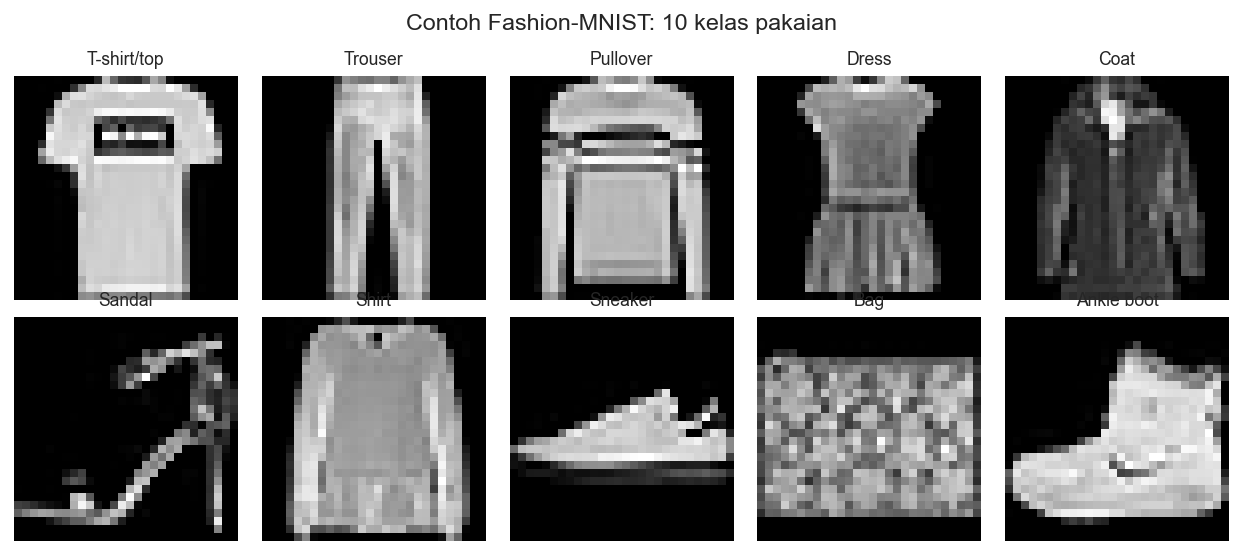

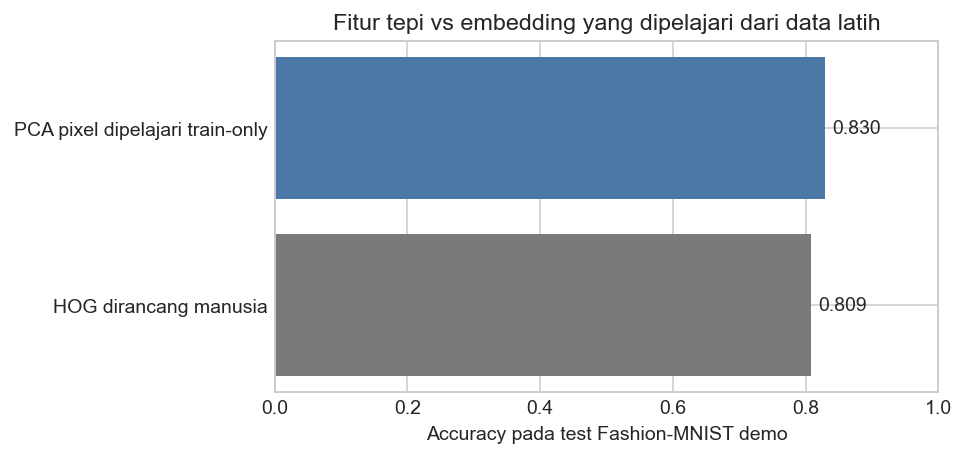

In [3]:
label_names = fashion_sample['label_names']
x_train = fashion_sample['x_train']
y_train = fashion_sample['y_train']

fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for label, ax in enumerate(axes.ravel()):
    idx = np.flatnonzero(y_train == label)[0]
    ax.imshow(x_train[idx], cmap='gray')
    ax.set_title(label_names[label], fontsize=9)
    ax.axis('off')
plt.suptitle('Contoh Fashion-MNIST: 10 kelas pakaian')
plt.tight_layout()
plt.show()

train_img = fashion[fashion['split'] == 'train']
test_img = fashion[fashion['split'] == 'test']
hog_cols = [c for c in fashion.columns if c.startswith('hog_')]
pca_cols = [c for c in fashion.columns if c.startswith('pca_')]

image_scores = pd.DataFrame([
    {'representasi': 'HOG dirancang manusia', 'accuracy': fit_score(train_img, test_img, hog_cols)},
    {'representasi': 'PCA pixel dipelajari train-only', 'accuracy': fit_score(train_img, test_img, pca_cols)},
])
print(image_scores.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
print(f"PCA menjelaskan {fashion_stats['pca_explained_variance_ratio_sum']:.1%} variasi pixel pada data latih demo.")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.barh(image_scores['representasi'], image_scores['accuracy'], color=['#7a7a7a', '#4c78a8'])
ax.set_xlim(0, 1)
ax.set_xlabel('Accuracy pada test Fashion-MNIST demo')
ax.set_title('Fitur tepi vs embedding yang dipelajari dari data latih')
for i, value in enumerate(image_scores['accuracy']):
    ax.text(value + 0.01, i, f'{value:.3f}', va='center')
plt.tight_layout()
plt.show()


## Audio: MFCC vs embedding log-mel PCA


          representasi  accuracy
         MFCC mean/std     0.950
log-mel PCA train-only     0.893
Speaker-holdout MFCC mean accuracy: 0.595
heldout_speaker  accuracy
       yweweler     0.716
           theo     0.722
        nicolas     0.530
          lucas     0.532
        jackson     0.656
         george     0.416


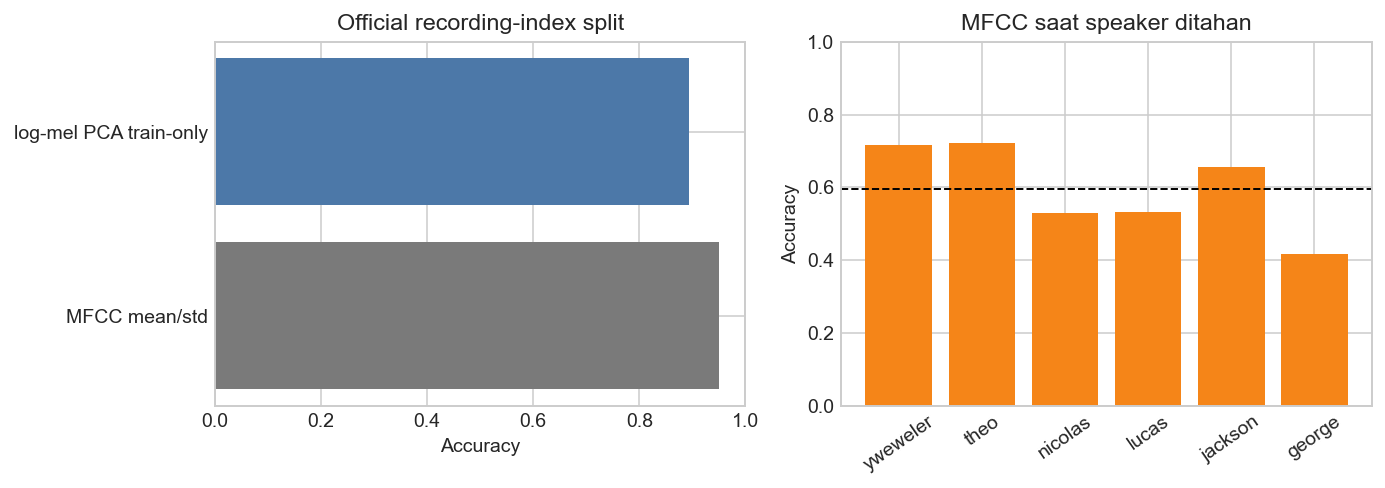

In [4]:
train_audio = fsdd[fsdd['official_split'] == 'train']
test_audio = fsdd[fsdd['official_split'] == 'test']
mfcc_cols = [c for c in fsdd.columns if c.startswith('mfcc_')]
logmel_cols = [c for c in fsdd.columns if c.startswith('logmel_pca_')]

audio_scores = pd.DataFrame([
    {'representasi': 'MFCC mean/std', 'accuracy': fit_score(train_audio, test_audio, mfcc_cols, target='digit')},
    {'representasi': 'log-mel PCA train-only', 'accuracy': fit_score(train_audio, test_audio, logmel_cols, target='digit')},
])
print(audio_scores.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
print(f"Speaker-holdout MFCC mean accuracy: {fsdd_stats['speaker_holdout_mfcc_accuracy_mean']:.3f}")
print(speaker_scores.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].barh(audio_scores['representasi'], audio_scores['accuracy'], color=['#7a7a7a', '#4c78a8'])
axes[0].set_xlim(0, 1)
axes[0].set_title('Official recording-index split')
axes[0].set_xlabel('Accuracy')
axes[1].bar(speaker_scores['heldout_speaker'], speaker_scores['accuracy'], color='#f58518')
axes[1].axhline(fsdd_stats['speaker_holdout_mfcc_accuracy_mean'], color='black', linewidth=1, linestyle='--')
axes[1].set_ylim(0, 1)
axes[1].set_title('MFCC saat speaker ditahan')
axes[1].tick_params(axis='x', rotation=35)
axes[1].set_ylabel('Accuracy')
plt.tight_layout()
plt.show()


>
> ?? **Amati.** Pada citra, embedding PCA train-only sedikit mengungguli HOG pada sampel Fashion-MNIST ini. Pada audio, MFCC justru lebih kuat daripada embedding log-mel PCA ringan. Ini bukan kontradiksi: representasi yang dipelajari mesin harus tetap diuji pada tugas dan domain lokal. FSDD juga memperlihatkan risiko identitas sumber: akurasi official split tinggi, tetapi turun tajam ketika speaker benar-benar ditahan.


## Section 2 - Mini Project

## Soal

Ulangi perbandingan citra pada **dua kelas Fashion-MNIST** yang lebih mirip, misalnya `Pullover` (2) vs `Coat` (4), atau `Sandal` (5) vs `Sneaker` (7).

Tugas:

1. Ambil data dari `mini_train` dan `mini_test` yang disiapkan di bawah.
2. Latih regresi logistik pada fitur HOG dan fitur PCA.
3. Bandingkan akurasi, lalu jelaskan kelas mana yang paling sering tertukar dan mengapa.

**Luaran:** kode ekstraksi fitur yang dipakai + perbandingan akurasi, plus 3-4 kalimat analisis.

**Kriteria penilaian:** (a) pengklasifikasi sama untuk kedua representasi; (b) *split* train/test tidak dicampur; (c) analisis trade-off fitur dirancang manusia vs dipelajari mesin.


In [5]:
# DATA AWAL (jangan diubah): dua kelas Fashion-MNIST yang bentuknya mirip.
kelas = {2: 'Pullover', 4: 'Coat'}
mini_train = train_img[train_img['label'].isin(kelas)].copy()
mini_test = test_img[test_img['label'].isin(kelas)].copy()
print('Train:', mini_train.shape, mini_train['label_name'].value_counts().to_dict())
print('Test :', mini_test.shape, mini_test['label_name'].value_counts().to_dict())
mini_train[['split', 'label', 'label_name']].head()


Train: (1200, 192) {'Pullover': 600, 'Coat': 600}
Test : (400, 192) {'Pullover': 200, 'Coat': 200}


,split,label,label_name
1200,train,2,Pullover
1201,train,2,Pullover
1202,train,2,Pullover
1203,train,2,Pullover
1204,train,2,Pullover


In [6]:
# Kerjakan di sini.
# Petunjuk: gunakan hog_cols dan pca_cols dari demo, lalu bandingkan accuracy pada mini_test.
